In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing libraries for the SR.

In [1]:
#| echo: true
import numpy as np
import matplotlib.pyplot as plt
from gplearn.genetic import SymbolicRegressor
import graphviz

Creating a function and drawing noisy observations from it.

In [2]:
#| echo: true
def true_law(X):
    return X[:, 0]**2 - 0.5 * np.cos(X[:, 1])

rng = np.random.RandomState(42)
X_train = rng.uniform(-2, 2, size=(200, 2))
y_train = true_law(X_train) + rng.normal(0, 0.05, size=200)

X_test = rng.uniform(-2, 2, size=(100, 2))
y_test = true_law(X_test)

Training the model.

In [3]:
#| echo: true
est_gp = SymbolicRegressor(population_size=2000,
                           generations=20, stopping_criteria=0.01,
                           p_crossover=0.7, p_subtree_mutation=0.1,
                           p_hoist_mutation=0.05, p_point_mutation=0.1,
                           max_samples=0.9, verbose=1,
                           parsimony_coefficient=0.01, random_state=42,
                           function_set=('add', 'sub', 'mul', 'div', 'cos', 'sin'))

est_gp.fit(X_train, y_train)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    19.73          8.28841        7         0.272313          0.24835     40.18s
   1     6.58          1.34506        3         0.263839         0.324619     28.90s
   2     7.22          1.34527        7         0.218505         0.243268     29.24s
   3     5.76          1.62976        7         0.195336          0.17832     25.15s
   4     3.74         0.880664        7         0.187003         0.253322     22.72s
   5     4.97         0.908279        8         0.182972         0.204203     25.31s
   6     6.25          1.08844       10        0.0501441        0.0485609     52.23s
   7     7.09          1.05202       10        0.0491968        0.0570867     28.55s
   8     7.43          1.01999       10        0.0484214        0.0640652  

,population_size,2000
,generations,20
,tournament_size,20
,stopping_criteria,0.01
,const_range,"(-1.0, ...)"
,init_depth,"(2, ...)"
,init_method,'half and half'
,function_set,"('add', ...)"
,metric,'mean absolute error'
,parsimony_coefficient,0.01
,p_crossover,0.7


Plotting the prediction against the true values, and printing the best equation found.

y = X0^2 - 0.5*cos(X1)
y_hat =  add(mul(-0.575, sin(cos(X1))), mul(X0, X0))



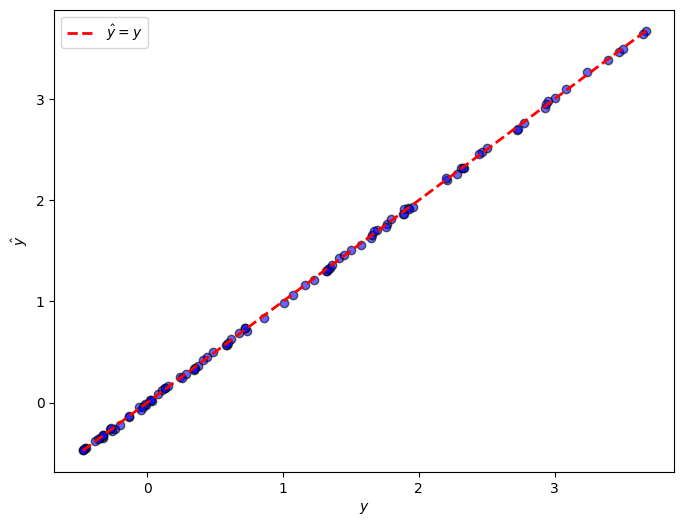

In [7]:
#| echo: true
print("y = X0^2 - 0.5*cos(X1)")
print("y_hat = ", est_gp._program)
print()

y_gp = est_gp.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_gp, alpha=0.6, color='blue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label=r"$\hat y = y$")
plt.xlabel(r"$y$")
plt.ylabel(r"$\hat y$")
plt.legend()
plt.show()

Showing the tree structure.

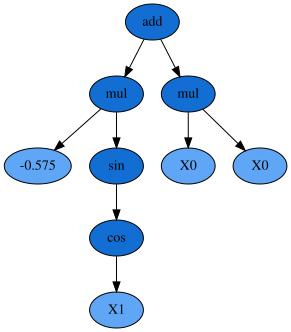

In [9]:
#| echo: true
dot_data = est_gp._program.export_graphviz()
graph = graphviz.Source(dot_data)
graph